[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Learning Rate Schedules and Warmup

Every experiment so far held the learning rate fixed for the whole run.  
Notebook 1 showed why a constant learning rate cannot be right at the end of
training: with noisy gradients it converges to a *region* around the minimum
rather than to the minimum itself, and the size of that region is set by $\eta$.
Shrinking $\eta$ over time shrinks the region.

Less obviously, a constant learning rate is often wrong at the *start* of
training too, and for a different reason, which is what **warmup** is for, and
why essentially every transformer you will encounter is trained with it.

This notebook covers both ends.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import math
import re
import time
from collections import Counter

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu')
print(f'Using {device} device')
torch.manual_seed(0)

Using mps device


## The noise floor, quantified

In Notebook 1 we evaluated SGD on a real two-parameter least-squares
problem and saw that the magnitude of the learning rate limited how close training can come to the minimum.
Let's revisit that.

In [2]:
from sklearn.datasets import load_diabetes

def two_feature_problem():
    """The two-parameter least-squares problem from notebook 1."""
    dataset = load_diabetes()
    columns = [dataset.feature_names.index(name) for name in ('bmi', 's5')]
    X = torch.tensor(dataset.data[:, columns], dtype=torch.float32)
    y = torch.tensor(dataset.target, dtype=torch.float32)
    return (X - X.mean(0)) / X.std(0), (y - y.mean()) / y.std()

X, y = two_feature_problem()
w_star = torch.linalg.lstsq(X, y.unsqueeze(1)).solution.squeeze(1)

def run_sgd(learning_rate, steps=20_000, init=(-1.0, -0.2), seed=0):
    """One-example SGD, with the learning rate a function of the step number.

    Returns the distance from the least-squares solution at every step."""
    generator = torch.Generator().manual_seed(seed)
    w = torch.tensor(init)
    distances = []
    for t in range(1, steps + 1):
        i = torch.randint(len(X), (1,), generator=generator)
        gradient = X[i].T @ (X[i] @ w - y[i])
        w = w - learning_rate(t) * gradient
        distances.append(float((w - w_star).norm()))
    return np.array(distances)

etas = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]
radii = []
print(f'{"eta":>8s} {"measured distance":>20s}')
for eta in etas:
    settled = run_sgd(lambda t, eta=eta: eta)[-10_000:]      # after it has settled
    radii.append(settled.mean())
    print(f'{eta:8.3f} {radii[-1]:20.4f}')

slope = np.polyfit(np.log(etas), np.log(radii), 1)[0]
print(f'\nfitting radius ~ eta^p gives p = {slope:.2f}')

     eta    measured distance
   0.100               0.2248
   0.050               0.1494
   0.020               0.0909
   0.010               0.0640
   0.005               0.0453
   0.002               0.0279

fitting radius ~ eta^p gives p = 0.53


The iterates never reach the minimum; they settle at a distance from it that
the learning rate controls.  However, a small learning rate that would allow us to get close, will cost in an overall slow training process.
The solution is to let the learning rate *change*: large enough early to make
progress, and shrinking towards zero so the noise floor shrinks with it.

## How fast should the learning rate go to zero?

So the constant has to go.  From now on the learning rate carries an
index: $\eta$ becomes $\eta_t$, computed according to a pre-specified
**schedule**.  Typically in large modelsthe scheduler is updated each optimizer *step*; 
schedules are sometimes advanced once per epoch instead.  
A PyTorch scheduler has its own `.step()`, separate from the
optimizer's, and the rate moves one tick each time it is called.

```python
for epoch in range(epochs):
    for X, y in loader:
        ...
        optimizer.step()
        scheduler.step()     # here the rate changes every update
    scheduler.step()         # here an update occurs once per epoch
```

The question is what sequence $\eta_1, \eta_2, \ldots$ to use, and the first
thing to pin down is how fast it is allowed to shrink.

Not arbitrarily fast, or we stop before arriving.  The classical conditions
capture both requirements at once:

$$\sum_{t=1}^{\infty} \eta_t = \infty
\qquad\text{and}\qquad
\sum_{t=1}^{\infty} \eta_t^2 < \infty.$$

**The first sum must diverge** so that the total distance the steps *could*
cover is unbounded — no starting point is out of reach, however far away the
minimum is.  A schedule whose steps sum to a finite number has committed in
advance to travelling at most that far, and if the minimum is further away it
will never arrive.

**The second sum must converge** so that the noise runs out of energy.  At step
$t$ the noise displaces the parameters by $\eta_t \times (\text{noise}_t)$.
These displacements are independent and zero-mean, so their *variances* add,
and the total variance the noise ever injects is proportional to
$\sum_t \eta_t^2 \sigma^2$.  When that sum converges the noise has a finite
budget: the later terms contribute vanishingly little and the iterates settle.
When it diverges the parameters keep being kicked with undiminished cumulative
variance, and they rattle around however long you train.

The first condition rules out decaying too fast, the second
decaying too slowly.  A schedule $\eta_t \propto t^{-\alpha}$ satisfies both
exactly when $\tfrac{1}{2} < \alpha \le 1$ — which is where the standard schedules
proportional to $t^{-1/2}$ and $t^{-1}$ come from.

> Robbins, H., & Monro, S. (1951). A stochastic approximation method.
> *The Annals of Mathematical Statistics*, 22(3), 400–407.

Deep learning practice does not follow these conditions especially closely —
finite training budgets make the asymptotics beside the point, and the schedules
that work best empirically are not always the ones the theory endorses.  But
the shape of the answer, *large steps early and small steps late*, is the same.

Let's verify that a decaying rate beats a constant one on our toy problem:

In [3]:
SCHEDULES = {
    'constant':            lambda t: 1.0,
    'polynomial t^-1/2':   lambda t: (1 + 0.01 * t) ** -0.5,
    'polynomial t^-1':     lambda t: (1 + 0.01 * t) ** -1.0,
    'exponential 0.999^t': lambda t: 0.999 ** t,
    'exponential 0.995^t': lambda t: 0.995 ** t,
}

eta0 = 0.2                                    # the rate every schedule starts from

for name, schedule in SCHEDULES.items():
    settled = run_sgd(lambda t, s=schedule: eta0 * s(t), steps=2000)[-100:]
    print(f'{name:22s} final distance {settled.mean():.4f}   '
          f'(rate has fallen to {schedule(2000):.1e} of its initial value)')

constant               final distance 0.4508   (rate has fallen to 1.0e+00 of its initial value)
polynomial t^-1/2      final distance 0.1841   (rate has fallen to 2.2e-01 of its initial value)
polynomial t^-1        final distance 0.0517   (rate has fallen to 4.8e-02 of its initial value)
exponential 0.999^t    final distance 0.1430   (rate has fallen to 1.4e-01 of its initial value)
exponential 0.995^t    final distance 0.0358   (rate has fallen to 4.4e-05 of its initial value)


Every decaying schedule beats the constant one.

The ordering *among* the decaying schedules is not what the theory alone
would suggest.  The two polynomial schedules satisfy
the Robbins–Monro conditions and the exponential ones do not — an exponential
has $\sum_t \eta_t < \infty$, so it commits in advance to covering only a
bounded total distance.  On this problem the aggressive exponential
nevertheless finishes first.

There is no contradiction: Robbins–Monro is an asymptotic guarantee, and we
have a budget of 2,000 steps.  The iterates get close to the minimum quickly
here, so a schedule that spends its distance early and then freezes is exactly
the right strategy, and one that keeps a slowly-decaying tail is just paying
for noise.  Asymptotic conditions describe what a schedule guarantees in the
limit; on a finite budget the question is whether it fits the problem.  This is
why fixed-budget schedules like cosine, which have no asymptotic
justification at all, dominate.

The exponential schedules also illustrate the real hazard of that family.  The
two differ only in the decay constant, and the one that decays too slowly ends
up several times worse: by step 2,000 it has only reached $13.5\%$ of its
initial rate, so most of the run was effectively at a constant learning rate.
The constant has to be matched to the length of the run.

## The schedules people actually use

A schedule is written as a **multiplier** $m(t)$: a dimensionless number that
starts at 1 and decays towards 0.  The learning rate at step $t$ is

$$\eta_t = \eta_0 \cdot m(t),$$

where $\eta_0$ is the **base learning rate**, the single value a grid search
would pick.  Splitting the schedule from the
base rate this way means one schedule can be reused at any base rate, and it is
the form PyTorch's `lr_scheduler` classes take.

The four shapes shown below are the most common.

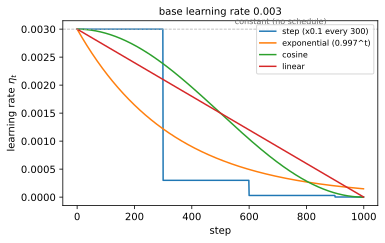

In [4]:
TOTAL = 1000
BASE_LR = 3e-3          # the base learning rate these multipliers scale

def step_decay(t, drop=0.1, every=300):
    return drop ** (t // every)

def exponential_decay(t, gamma=0.997):
    return gamma ** t

def cosine_decay(t, total=TOTAL, floor=0.0):
    return floor + (1 - floor) * 0.5 * (1 + math.cos(math.pi * t / total))

def linear_decay(t, total=TOTAL):
    return max(0.0, 1 - t / total)

t = np.arange(TOTAL)
plt.figure(figsize=(5.5, 3.5))
for name, fn in [('step (x0.1 every 300)', step_decay),
                 ('exponential (0.997^t)', exponential_decay),
                 ('cosine', cosine_decay),
                 ('linear', linear_decay)]:
    plt.plot(t, [BASE_LR * fn(int(i)) for i in t], label=name)
plt.axhline(BASE_LR, color='0.7', lw=0.8, ls='--')
plt.text(TOTAL * 0.55, BASE_LR * 1.03, 'constant (no schedule)',
         fontsize=8, color='0.4')
plt.xlabel('step'); plt.ylabel(r'learning rate $\eta_t$')
plt.title(f'base learning rate {BASE_LR:g}', fontsize=10)
plt.legend(fontsize=8); plt.tight_layout()

**Step decay** — multiply by $0.1$ at fixed milestones.  This is the classical
recipe for convolutional networks, and the source of the characteristic
staircase in training curves: the loss plateaus, the rate drops, and
the loss immediately falls again. 
The plateau is the noise floor; decreasing $\eta$ tenfold cuts the floor and
reveals progress that was ready to be made.

**Exponential decay** is the smooth version, and needs care for the reason the
previous experiment showed.

**Cosine decay** starts slow, spends most of the budget in the middle range,
and eases to zero at the end.  It is the current default for transformers and
for most large-scale training.  It has no free parameters beyond the total
length — which is also its one real drawback: you must decide the length of the
run in advance, and stopping a cosine schedule early leaves you at a learning
rate that was never meant to be a stopping point.

**Linear decay to zero** is competitive with cosine and simpler still.  Recent
work on large-scale training has moved back towards it.

## Warmup, and why transformers need it

Everything above is about the end of training.  Now the beginning.

The last notebook derived Adam's bias correction from the fact that
$\mathbf{s}_t$, the second-moment accumulator, starts at zero and takes about
$1/(1-\beta_2) \approx 1000$ steps to fill.  Bias correction fixes the
*expectation* — it rescales $\mathbf{s}_t$ so that it is an unbiased estimate
of $\mathbb{E}[g^2]$ at every $t$.  What it cannot fix is the **variance**.  At
step 10, $\hat{\mathbf{s}}_t$ is an average over about ten samples, correctly
scaled and extremely noisy.  It sits in a denominator, and a noisy denominator
occasionally becomes small, which produces occasional enormous steps.

Early in training is the worst possible time for that.  The parameters are
random, the loss surface has not been explored, and one oversized step can push
the network into a region characterized by saturated activations, or a collapsed attention
pattern.  As a result, it can spend the rest of the run recovering from the catastrophe.

**Warmup** is the simple fix: start at a learning rate
near zero and ramp it up linearly over the first few hundred or few thousand
steps, then hand over to a decay schedule.  The unreliable early estimates are
multiplied by a small number, and by the time the learning rate is at full
value the estimates are trustworthy.

Warmup entered common use through the original transformer paper, whose
schedule was warmup followed by $t^{-1/2}$ decay; the modern form is warmup
followed by cosine.  It is not exclusive to Adam, but it is where you will most often see it required rather than merely helpful.

In PyTorch code you can supply a custom learning rate schedule with `SequentialLR`.

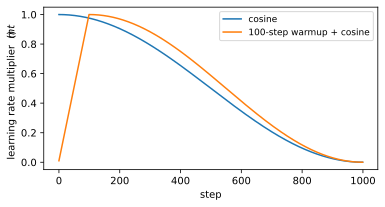

In [5]:
def warmup_cosine(t, warmup=100, total=TOTAL, floor=0.0):
    if t < warmup:
        return (t + 1) / warmup
    progress = (t - warmup) / max(1, total - warmup)
    return floor + (1 - floor) * 0.5 * (1 + math.cos(math.pi * progress))

plt.figure(figsize=(5.5, 3))
plt.plot(t, [cosine_decay(int(i)) for i in t], label='cosine')
plt.plot(t, [warmup_cosine(int(i)) for i in t], label='100-step warmup + cosine')
plt.xlabel('step'); plt.ylabel('learning rate multiplier  $m(t)$')
plt.legend(fontsize=9); plt.tight_layout()

## On a real model

Rebuild the language model from the previous notebook and put the schedules to
work.  The code is unchanged, so this section is short.

In [6]:
CONTEXT, BATCH = 32, 32
CORPUS = '../data/tinystories.txt'
N_CHARS = 2_000_000

def load_words(path, n_chars=N_CHARS, min_count=2):
    text = open(path, encoding='utf-8').read()[:n_chars].lower()
    words = re.findall(r"[a-z']+|[.,!?;]", text)
    counts = Counter(words)
    vocab = ['<unk>'] + [w for w, c in counts.most_common() if c >= min_count]
    stoi = {w: i for i, w in enumerate(vocab)}
    return torch.tensor([stoi.get(w, 0) for w in words], dtype=torch.long), vocab

def batches(ids, n_batches, batch_size=BATCH, context=CONTEXT, seed=0):
    generator = torch.Generator().manual_seed(seed)
    top = len(ids) - context - 1
    for _ in range(n_batches):
        start = torch.randint(0, top, (batch_size,), generator=generator)
        yield (torch.stack([ids[k:k + context] for k in start]),
               torch.stack([ids[k + 1:k + context + 1] for k in start]))


class Block(nn.Module):
    def __init__(self, d, heads, ffn):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attention = nn.MultiheadAttention(d, heads, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.GELU(), nn.Linear(ffn, d))

    def forward(self, X, mask):
        Z = self.ln1(X)
        attended, _ = self.attention(Z, Z, Z, attn_mask=mask, need_weights=False)
        X = X + attended
        return X + self.ffn(self.ln2(X))


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d=128, heads=4, ffn=512, blocks=2,
                 context=CONTEXT):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d)
        self.pos = nn.Embedding(context, d)
        self.blocks = nn.ModuleList([Block(d, heads, ffn) for _ in range(blocks)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab_size, bias=False)
        self.head.weight = self.emb.weight
        self.register_buffer('mask', torch.triu(
            torch.full((context, context), float('-inf')), diagonal=1))

    def forward(self, X):
        t = X.shape[1]
        Z = self.emb(X) + self.pos(torch.arange(t, device=X.device))
        for block in self.blocks:
            Z = block(Z, self.mask[:t, :t])
        return self.head(self.ln_f(Z))


ids, vocab = load_words(CORPUS)
print(f'{len(ids):,} tokens, vocabulary {len(vocab):,}')
print(f'{600 * BATCH * CONTEXT / len(ids):.1f} passes over the corpus in 600 steps')

444,903 tokens, vocabulary 4,648
1.4 passes over the corpus in 600 steps


In [7]:
def train_lm(ids, vocab, lr, schedule=None, steps=800, seed=0, clip=1.0,
             optimizer_cls=torch.optim.Adam):
    """Train TinyGPT with an optional per-step learning rate multiplier."""
    torch.manual_seed(seed)
    model = TinyGPT(len(vocab)).to(device)
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    scheduler = (torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)
                 if schedule is not None else None)
    losses = []
    for X, Y in batches(ids, steps):
        X, Y = X.to(device), Y.to(device)
        loss = F.cross_entropy(model(X).reshape(-1, len(vocab)), Y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        losses.append(loss.item())
        if not math.isfinite(losses[-1]):
            break
    return losses

def final_loss(losses, window=50):
    return float(np.mean(losses[-window:])) if math.isfinite(losses[-1]) else float('inf')

`LambdaLR` takes a function of the step number returning a *multiplier* on the
base learning rate — exactly the schedule functions plotted above.  That is the
most transparent of PyTorch's scheduler interfaces and the reason we use it
here; `CosineAnnealingLR`, `StepLR`, `OneCycleLR` provide specific learning rate schedules.

Let's run all three schedules at two base learning rates: the one that won the sweep
in the previous notebook, and one ten times larger.

In [8]:
STEPS = 600

runs = {
    'constant':        None,
    'cosine':          lambda t: cosine_decay(t, total=STEPS),
    'warmup + cosine': lambda t: warmup_cosine(t, warmup=60, total=STEPS),
}

results, curves = {}, {}
print(f'{"base lr":>8s}  {"schedule":<16s} {"loss":>7s} {"perplexity":>11s}')
for lr in [3e-3, 3e-2]:
    for name, schedule in runs.items():
        losses = train_lm(ids, vocab, lr=lr, schedule=schedule, steps=STEPS)
        score = final_loss(losses)
        results[(lr, name)] = score
        curves[(lr, name)] = losses
        shown = 'diverged' if not math.isfinite(score) else f'{math.exp(score):11.1f}'
        print(f'{lr:8g}  {name:<16s} {score:7.3f} {shown:>11s}')
    print()

 base lr  schedule            loss  perplexity
   0.003  constant           4.358        78.1
   0.003  cosine             4.683       108.1
   0.003  warmup + cosine    4.651       104.7

    0.03  constant           5.563       260.5
    0.03  cosine             5.359       212.5
    0.03  warmup + cosine    4.995       147.6



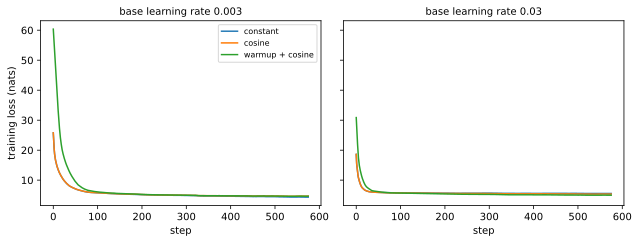

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, lr in zip(axes, [3e-3, 3e-2]):
    for name in runs:
        losses = curves[(lr, name)]
        ax.plot(np.convolve(losses, np.ones(25) / 25, mode='valid'), label=name)
    ax.set_title(f'base learning rate {lr:g}', fontsize=10)
    ax.set_xlabel('step')
axes[0].set_ylabel('training loss (nats)'); axes[0].legend(fontsize=8)
plt.tight_layout()

This result is more interesting than a clean win would have been, so read the
two blocks carefully.

**At the good learning rate, decay makes things worse.**  Constant reaches
$4.36$; cosine reaches $4.69$ and warmup+cosine $4.65$.  That looks like a
contradiction of everything above, and it is not.  Decay pays off *once you are
at the noise floor*, and after 600 steps this model is nowhere near it — the
loss curve is still falling steeply at the end of the run.  Cutting the
learning rate in that regime does not reduce noise you are limited by; it just
slows down learning you were still doing.  A schedule that anneals to zero over
a budget shorter than the model needs is simply a shorter run.

**At the too-large learning rate, the ordering reverses.**  Constant reaches
$5.53$, cosine $5.38$, warmup+cosine $5.15$.  All three are worse than the
well-tuned constant run — you cannot schedule your way out of a bad base rate —
but the schedules recover a meaningful part of the damage, and the ordering
constant $<$ cosine $<$ warmup+cosine is exactly what the arguments above
predict.

On this budget, then, **schedules bought robustness rather than a better
optimum.** That is close to what they are for in practice.  At scale you
get one run, cannot sweep the learning rate over it, and need the setting you
chose to work; a schedule widens the range of base rates that do.  The benefit
that shows up as a lower final loss requires a budget long enough to reach the
noise floor, which exercise 3 asks you to confirm by running longer.

Two further caveats.  This is a small model on a small corpus, so the warmup
effect is milder than it would be at scale — warmup becomes more important as
models get deeper and batches get larger, and past a few dozen layers it is
usually not optional.  And gradient clipping is on (`clip=1.0`), which is
itself a defence against precisely the oversized early steps that warmup
addresses.  The two overlap in their purpose, and an exercise below separates them.

## Choosing the base learning rate

One practical note to close on, because grid search over full training runs is
not how this is done in practice.

The **learning rate range test** trains for a few hundred steps while
increasing $\eta$ exponentially, and plots loss against $\eta$.  The loss falls,
flattens, and then rises sharply; a good base rate is somewhat below where it
shoots up.  It costs one short run instead of a number of full ones.

ran 283 steps, from lr 1.0e-05 to 5.0e-01
the smoothed loss is lowest at lr = 6.1e-02
the usual rule is to back off by 3x to 10x: 6.1e-03 to 2.0e-02


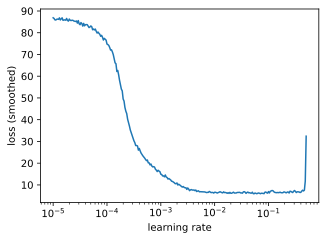

In [16]:
def lr_range_test(ids, vocab, lo=1e-5, hi=1.0, steps=300, seed=0):
    """Increase the learning rate exponentially; record the loss along the way."""
    torch.manual_seed(seed)
    model = TinyGPT(len(vocab)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lo)
    gamma = (hi / lo) ** (1 / steps)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma)

    rates, losses = [], []
    for X, Y in batches(ids, steps):
        X, Y = X.to(device), Y.to(device)
        loss = F.cross_entropy(model(X).reshape(-1, len(vocab)), Y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        rates.append(optimizer.param_groups[0]['lr'])
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        # stop once the loss has clearly turned back up
        if not math.isfinite(losses[-1]) or losses[-1] > 3 * min(losses):
            break
    return np.array(rates), np.array(losses)

rates, losses = lr_range_test(ids, vocab)
best = rates[int(np.argmin(losses))]

plt.figure(figsize=(5, 3.5))
plt.plot(rates, losses)
plt.xscale('log'); plt.xlabel('learning rate'); plt.ylabel('loss (smoothed)')

print(f'ran {len(losses)} steps, from lr {rates[0]:.1e} to {rates[-1]:.1e}')
print(f'the loss is lowest at lr = {best:.1e}')
print(f'the usual rule is to back off by 3x to 10x: '
      f'{best / 10:.1e} to {best / 3:.1e}')

The sweep in the previous notebook chose $3\times10^{-3}$.
So the test landed a little above the answer — the conservative end of its
range is within a factor of three of the optimum, the aggressive end
within a factor of ten.  **The range test finds the right order of magnitude
from a single run of a few hundred steps, and not much better than that.**
Given that learning rates are searched on a logarithmic scale and this cost one
run instead of a dozen, the right order of magnitude is usually what you can expect
from it.

Two reasons it reads high.  The curve's minimum is where the loss is falling
*fastest*, which is close to where the run is least stable, and that is not
where you want to sit for the whole of training; hence the back-off rule.  And
the test measures which rate is best over a couple of hundred steps at a
*ramping* rate, which systematically favours larger rates than a long run at a
constant one.

## Summary

* A constant learning rate leaves stochastic optimization at a noise floor.
  Its radius scales as $\sqrt{\eta}$, requiring a learning rate taht converges to zero.
* The Robbins–Monro conditions — $\sum \eta_t = \infty$ and
  $\sum \eta_t^2 < \infty$ — say the steps must be able to cover unbounded
  distance while accumulating bounded noise.  $\eta_t \propto t^{-\alpha}$ with
  $\tfrac12 < \alpha \le 1$ satisfies both; exponential decay satisfies
  neither, and still wins on a fixed budget.  The conditions are asymptotic and
  training runs are not.
* Step decay is the classical convolutional-network recipe and produces the
  staircase-shaped loss curve; cosine and linear decay to zero are the current
  defaults for large-scale training.  Both require committing to a total number
  of steps in advance.
* Warmup ramps the learning rate up over the first few hundred steps.  It exists
  because Adam's second-moment estimate is correctly scaled but high-variance
  early on, and a noisy denominator produces occasional large steps at the
  worst possible moment.
* On our 600-step budget, neither decay nor warmup beat a well-tuned constant
  rate — the model had not yet reached its noise floor, and annealing early
  just shortens the run.  What they did buy was **robustness**: at a base rate
  ten times too large, the schedules recovered a good part of the loss, in the
  order the theory predicts.  That is usually the reason to use them.
* The learning rate range test found the right order of magnitude from one run
  of a few hundred steps.  Treat it as the starting
  point for a short sweep rather than as the answer.


## Exercises


2. Add a schedule to `SCHEDULES` that decays as $t^{-1/4}$ and one that decays
   as $t^{-2}$.  Neither satisfies the Robbins–Monro conditions.  Predict how
   each fails before running it — and then explain why, on a 2,000-step
   budget, the $t^{-2}$ schedule may nevertheless do perfectly well.
3. The text claims decay lost at 800 steps because the model had not reached
   its noise floor.  Test it: rerun `constant` and `cosine` at `lr=3e-3` with
   `steps=3000`.  At what budget does cosine overtake the constant rate?  (On a
   GPU this is a couple of minutes; on a CPU, closer to ten.)
4. Run the cosine schedule for 800 steps but *stop it at step 400*, and compare
   the loss with a cosine schedule set up for a 400-step budget.  This is the
   cost of having to commit to the run length in advance.  How large is it?
5. Implement the original transformer schedule — linear warmup followed by
   $t^{-1/2}$ decay — as a `LambdaLR` function, and compare it with
   warmup + cosine at the same warmup length.
6. Vary the warmup length over $\{0, 20, 80, 300\}$ steps at a base learning
   rate of $3\times10^{-2}$.  Is there an optimum, and does it come with a cost
   at the smaller learning rates?
7. Turn off gradient clipping (`clip=float('inf')`) and repeat the learning
   rate table.  How much of warmup's benefit was clipping doing?
8. Run the learning rate range test on the $V = 50$ capped corpus from the
   previous notebook, and on the regression problem from notebook 2.  Does the
   curve have the same shape in all three cases?  Where the shape differs, say
   what about the problem explains it.